# 00 Data Calibration

This notebook extracts empirical parameters from the real DataCo Global Supply Chain dataset (`DataCoSupplyChainDataset.csv`) to calibrate our synthetic supply chain data generator. It analyzes shipping delay distributions, category late-delivery baseline rates, geographic volume concentration, and demand seasonality.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Section 1 — Load and Explore

In this section, we load the raw DataCo Global Supply Chain Dataset and perform initial exploratory data analysis (EDA). We inspect the dimensions, data types, and missing values across all columns. We then narrow our scope to key columns required for analyzing delivery performance, demand volumes, product category patterns, and geographic concentration. Finally, we display value counts for critical categorical features like `Delivery Status` and `Product Category Name`.

In [2]:
# 1. Load the dataset
dataset_path = "../data/raw/DataCoSupplyChainDataset.csv"
print(f"Loading dataset from: {dataset_path}")
df_raw = pd.read_csv(dataset_path, encoding='latin1')

# 2. Print shape, dtypes, and null counts for all columns
print(f"Dataset Shape: {df_raw.shape}")
print("\n--- Columns, Data Types, and Null Counts ---")
info_df = pd.DataFrame({
    'Dtype': df_raw.dtypes,
    'Null Count': df_raw.isnull().sum()
})
print(info_df)

# 3. Rename required columns for clarity
rename_dict = {
    'Category Name': 'Product Category Name',
    'order date (DateOrders)': 'order date'
}
df_raw = df_raw.rename(columns=rename_dict)

# 4. Focus on selected columns
selected_cols = [
    'Days for shipping (real)', 
    'Days for shipment (scheduled)', 
    'Delivery Status', 
    'Order Item Quantity', 
    'Order Item Total', 
    'Product Category Name', 
    'Order Country', 
    'Late_delivery_risk', 
    'order date'
]
df = df_raw[selected_cols].copy()
print(f"\nFocused Dataset Shape: {df.shape}")
print("\n--- Focused Dataset Sample ---")
print(df.head())

# 5. Show value counts for Delivery Status and Product Category Name
print("\n--- Delivery Status Value Counts ---")
print(df['Delivery Status'].value_counts())

print("\n--- Product Category Name Value Counts (Top 10) ---")
print(df['Product Category Name'].value_counts().head(10))

Loading dataset from: ../data/raw/DataCoSupplyChainDataset.csv


Dataset Shape: (180519, 53)

--- Columns, Data Types, and Null Counts ---
                                 Dtype  Null Count
Type                               str           0
Days for shipping (real)         int64           0
Days for shipment (scheduled)    int64           0
Benefit per order              float64           0
Sales per customer             float64           0
Delivery Status                    str           0
Late_delivery_risk               int64           0
Category Id                      int64           0
Category Name                      str           0
Customer City                      str           0
Customer Country                   str           0
Customer Email                     str           0
Customer Fname                     str           0
Customer Id                      int64           0
Customer Lname                     str           8
Customer Password                  str           0
Customer Segment                   str           0
Customer

## Section 2 — Delivery Delay Distribution

Here we calculate the actual shipping delay as the difference between the real shipping time and the scheduled shipping time:
$$\text{delay\_days} = \text{Days for shipping (real)} - \text{Days for shipment (scheduled)}$$
A positive value indicates a late delivery, zero indicates exactly on-time delivery, and a negative value means the delivery was shipped ahead of schedule.

To model this delay mathematically, we fit both a **Normal distribution** and a **Gamma distribution** to the empirical delay data using maximum likelihood estimation. We evaluate the fits using the **Kolmogorov-Smirnov (KS) test** and plot both fitted probability density functions (PDFs) overlaid on the empirical distribution histogram to identify the best-fitting distribution.

--- Normal Distribution Fit ---
Parameters: Mean (mu) = 0.5658, Std Dev (sigma) = 1.4910
KS Statistic = 0.1873, p-value = 0.0000e+00

--- Gamma Distribution Fit ---
Parameters: Shape (alpha) = 3713.5615, Location (loc) = -90.2796, Scale (beta) = 0.0245
KS Statistic = 0.1893, p-value = 0.0000e+00



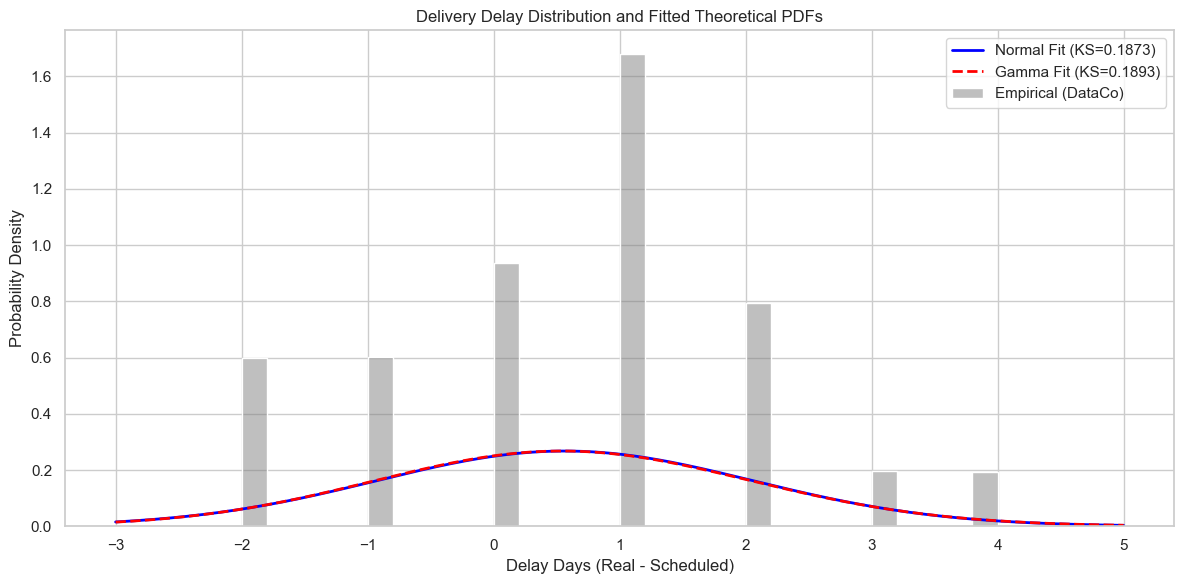

The winning distribution based on the lowest Kolmogorov-Smirnov statistic is: Normal


In [3]:
# 1. Compute delay_days
df['delay_days'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# 2. Fit Normal and Gamma distributions
delay_data = df['delay_days'].dropna()

# Fit Normal distribution
norm_mu, norm_std = stats.norm.fit(delay_data)

# Fit Gamma distribution
gamma_shape, gamma_loc, gamma_scale = stats.gamma.fit(delay_data)

# 3. Run Kolmogorov-Smirnov test for both fits
ks_stat_norm, ks_p_norm = stats.kstest(delay_data, 'norm', args=(norm_mu, norm_std))
ks_stat_gamma, ks_p_gamma = stats.kstest(delay_data, 'gamma', args=(gamma_shape, gamma_loc, gamma_scale))

print("--- Normal Distribution Fit ---")
print(f"Parameters: Mean (mu) = {norm_mu:.4f}, Std Dev (sigma) = {norm_std:.4f}")
print(f"KS Statistic = {ks_stat_norm:.4f}, p-value = {ks_p_norm:.4e}\n")

print("--- Gamma Distribution Fit ---")
print(f"Parameters: Shape (alpha) = {gamma_shape:.4f}, Location (loc) = {gamma_loc:.4f}, Scale (beta) = {gamma_scale:.4f}")
print(f"KS Statistic = {ks_stat_gamma:.4f}, p-value = {ks_p_gamma:.4e}\n")

# 4. Plot empirical delay distribution and fitted PDFs
plt.figure(figsize=(12, 6))

# Plot empirical histogram with KDE
sns.histplot(delay_data, stat='density', bins=30, alpha=0.5, label='Empirical (DataCo)', color='gray')

# Plot fitted Normal PDF
x_range = np.linspace(delay_data.min() - 1, delay_data.max() + 1, 500)
pdf_norm = stats.norm.pdf(x_range, norm_mu, norm_std)
plt.plot(x_range, pdf_norm, label=f'Normal Fit (KS={ks_stat_norm:.4f})', color='blue', linewidth=2)

# Plot fitted Gamma PDF
pdf_gamma = stats.gamma.pdf(x_range, gamma_shape, gamma_loc, gamma_scale)
plt.plot(x_range, pdf_gamma, label=f'Gamma Fit (KS={ks_stat_gamma:.4f})', color='red', linewidth=2, linestyle='--')

plt.title('Delivery Delay Distribution and Fitted Theoretical PDFs')
plt.xlabel('Delay Days (Real - Scheduled)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Record the winning fit parameters
winning_dist = 'Gamma' if ks_stat_gamma < ks_stat_norm else 'Normal'
print(f"The winning distribution based on the lowest Kolmogorov-Smirnov statistic is: {winning_dist}")

## Section 3 — Late Delivery Rate by Product Category

Understanding reliability across different product offerings is essential for supply chain risk modeling. In this section, we compute the baseline late delivery rate for each product category, defined as:
$$\text{Late Delivery Rate} = \frac{\text{Orders with \"Late delivery\" Status}}{\text{Total Orders}}$$
We then visualize these rates using a horizontal bar chart. These rates serve as category-specific baseline probabilities of shipping failures (late deliveries) in the synthetic data generator.

--- Late Delivery Rates by Product Category (Top 10) ---
Product Category Name  Late Delivery Rate
    Golf Bags & Carts            0.688525
             Lacrosse            0.600583
         Pet Supplies            0.589431
             Cameras             0.581081
    Strength Training            0.576577
      As Seen on  TV!            0.573529
                Music            0.571429
          Accessories            0.569663
  Fitness Accessories            0.569579
               Books             0.565432


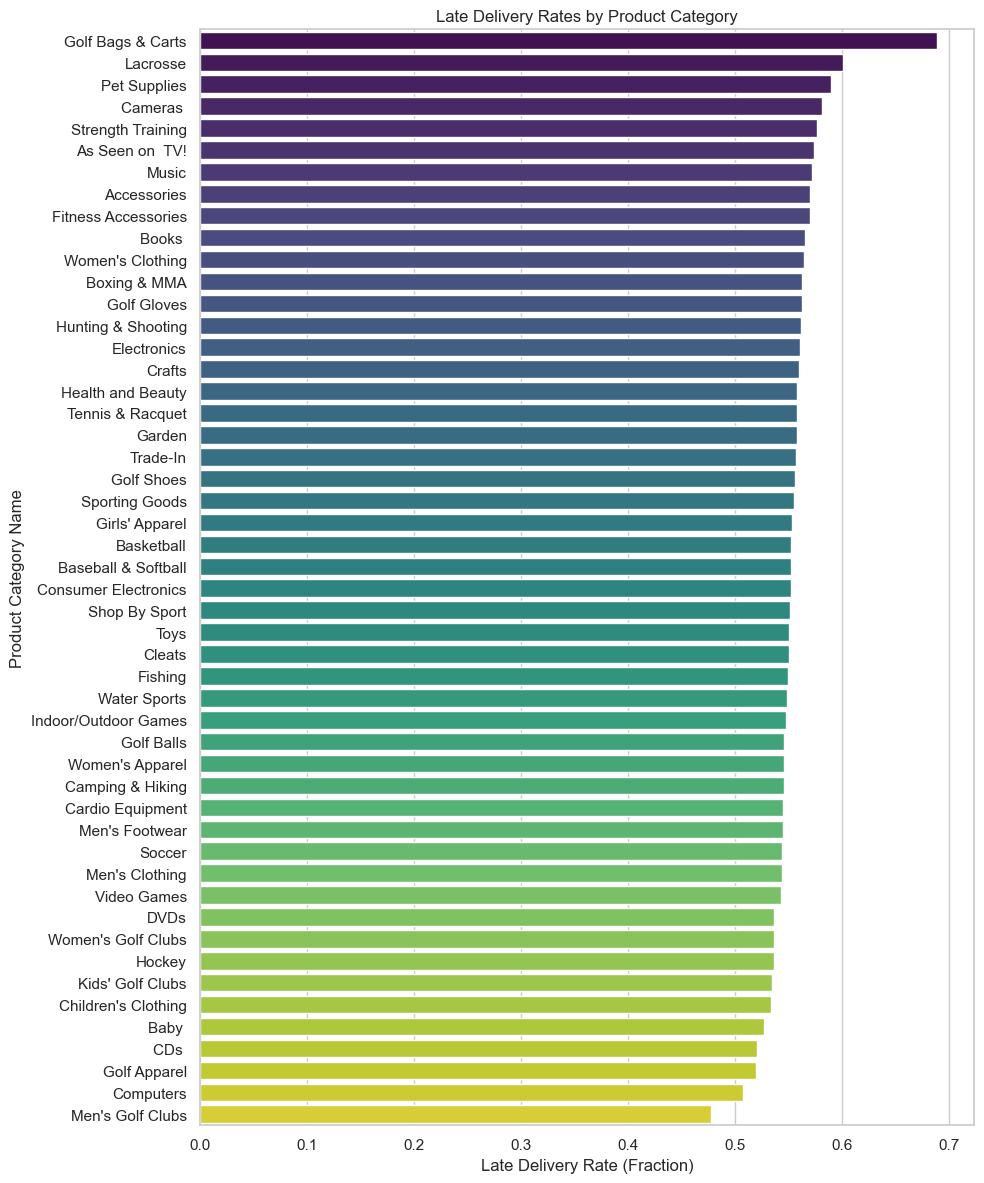

In [4]:
# 1. Compute late delivery rate by Product Category Name
# Group by category and compute mean of Delivery Status == 'Late delivery'
late_by_cat = df.groupby('Product Category Name').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').mean()
).reset_index(name='Late Delivery Rate')

# Sort descending
late_by_cat = late_by_cat.sort_values(by='Late Delivery Rate', ascending=False)

print("--- Late Delivery Rates by Product Category (Top 10) ---")
print(late_by_cat.head(10).to_string(index=False))

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 12))
sns.barplot(
    data=late_by_cat,
    x='Late Delivery Rate',
    y='Product Category Name',
    palette='viridis'
)
plt.title('Late Delivery Rates by Product Category')
plt.xlabel('Late Delivery Rate (Fraction)')
plt.ylabel('Product Category Name')
plt.tight_layout()
plt.show()

## Section 4 — Supply Concentration by Country

A classic vulnerability in supply chains is the concentration of supply (or order volume) in a small number of countries. In this section, we analyze the distribution of total order volume (measured by `Order Item Quantity`) across various destination countries. We build a Pareto chart showing the cumulative percentage of order volume and calculate the cumulative volume shares of the top 1, top 3, and top 5 countries to quantify geographic dependency.

--- Geographic Supply Concentration Statistics ---
Top 1 Country (Estados Unidos) Share: 14.17%
Top 3 Countries Share: 28.88%
Top 5 Countries Share: 38.56%


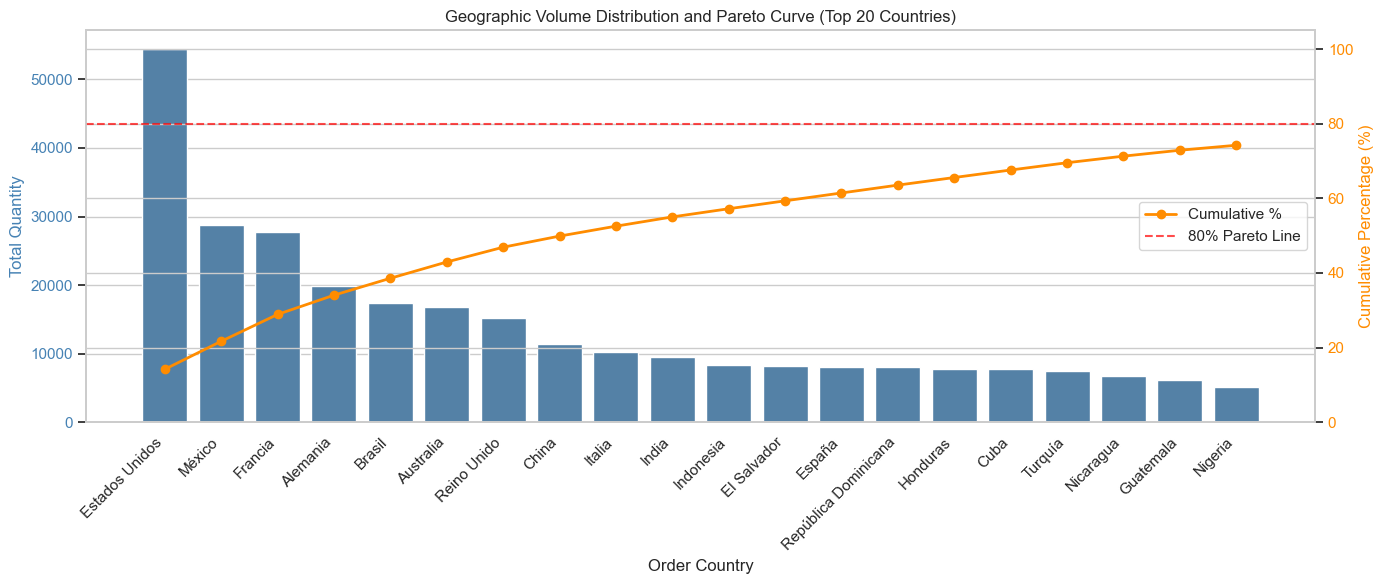

In [5]:
# 1. Compute total volume by country
country_vol = df.groupby('Order Country')['Order Item Quantity'].sum().reset_index(name='Total Quantity')
country_vol = country_vol.sort_values(by='Total Quantity', ascending=False).reset_index(drop=True)

# 2. Calculate percentages and cumulative shares
total_volume = country_vol['Total Quantity'].sum()
country_vol['Percentage'] = (country_vol['Total Quantity'] / total_volume) * 100
country_vol['Cumulative Percentage'] = country_vol['Percentage'].cumsum()

# 3. Print concentration statistics for top 1, 3, and 5 countries
top_1_share = country_vol.loc[0, 'Cumulative Percentage']
top_3_share = country_vol.loc[2, 'Cumulative Percentage']
top_5_share = country_vol.loc[4, 'Cumulative Percentage']

print("--- Geographic Supply Concentration Statistics ---")
print(f"Top 1 Country ({country_vol.loc[0, 'Order Country']}) Share: {top_1_share:.2f}%")
print(f"Top 3 Countries Share: {top_3_share:.2f}%")
print(f"Top 5 Countries Share: {top_5_share:.2f}%")

# 4. Plot Pareto Chart (using top 20 countries for visual clarity)
top_n = 20
country_vol_top = country_vol.head(top_n).copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for volumes
sns.barplot(
    data=country_vol_top,
    x='Order Country',
    y='Total Quantity',
    color='steelblue',
    ax=ax1
)
ax1.set_title(f'Geographic Volume Distribution and Pareto Curve (Top {top_n} Countries)')
ax1.set_xlabel('Order Country')
ax1.set_ylabel('Total Quantity', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Line chart for cumulative percentages
ax2 = ax1.twinx()
ax2.plot(
    country_vol_top['Order Country'],
    country_vol_top['Cumulative Percentage'],
    color='darkorange',
    marker='o',
    linewidth=2,
    label='Cumulative %'
)
ax2.set_ylabel('Cumulative Percentage (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 105)

# Add line indicating 80% Pareto threshold
ax2.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% Pareto Line')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

## Section 5 — Demand Seasonality

In this section, we analyze seasonal fluctuations in ordering patterns. We parse the `order date` column, extract the transaction month, and calculate the average monthly volume (total quantity per month) across all years of data. We then compute a monthly seasonality multiplier:
$$\text{Multiplier}_m = \frac{\text{Average Volume for Month } m}{\text{Overall Monthly Average Volume}}$$
These multipliers allow the synthetic generator to modulate transaction rates month-by-month, reproducing realistic, seasonal demand cycles.

--- Monthly Demand Seasonality Multipliers ---
 Month  Average Volume  Multiplier
     1     9294.750000    0.892810
     2    10757.666667    1.033331
     3    11695.666667    1.123430
     4    11228.000000    1.078509
     5    11512.666667    1.105852
     6    10801.666667    1.037557
     7    11514.333333    1.106012
     8    11463.333333    1.101114
     9    11050.666667    1.061475
    10     8709.666667    0.836609
    11     8337.000000    0.800813
    12     8562.666667    0.822489


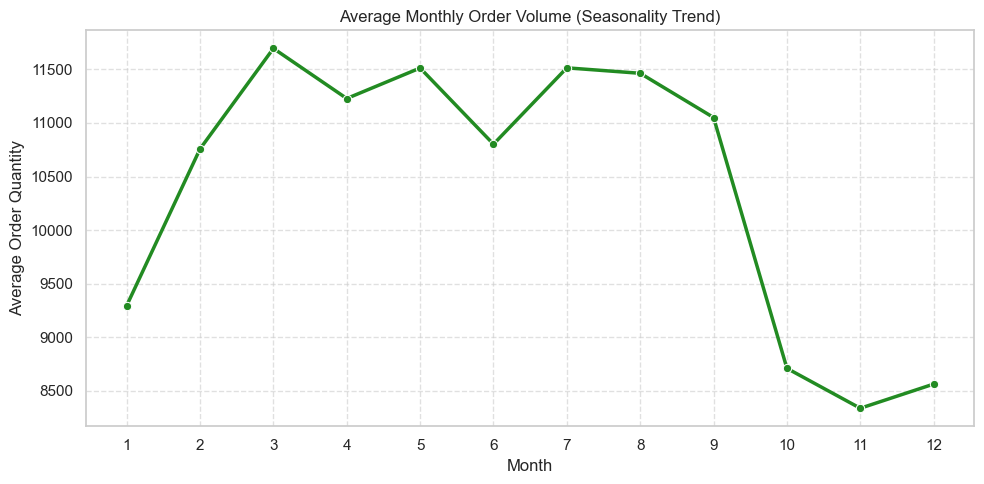

In [6]:
# 1. Parse dates and extract month
df['order_date_dt'] = pd.to_datetime(df['order date'], errors='coerce')
# Drop rows with invalid dates if any
df_date = df.dropna(subset=['order_date_dt']).copy()
df_date['Year'] = df_date['order_date_dt'].dt.year
df_date['Month'] = df_date['order_date_dt'].dt.month

# 2. Compute total volume by year and month
monthly_totals = df_date.groupby(['Year', 'Month'])['Order Item Quantity'].sum().reset_index()

# 3. Compute average volume for each month across all years
monthly_averages = monthly_totals.groupby('Month')['Order Item Quantity'].mean().reset_index()
monthly_averages = monthly_averages.rename(columns={'Order Item Quantity': 'Average Volume'})

# 4. Compute monthly multiplier
overall_average = monthly_averages['Average Volume'].mean()
monthly_averages['Multiplier'] = monthly_averages['Average Volume'] / overall_average

print("--- Monthly Demand Seasonality Multipliers ---")
print(monthly_averages.to_string(index=False))

# 5. Plot line chart of monthly averages
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_averages,
    x='Month',
    y='Average Volume',
    marker='o',
    color='forestgreen',
    linewidth=2.5
)
plt.title('Average Monthly Order Volume (Seasonality Trend)')
plt.xlabel('Month')
plt.ylabel('Average Order Quantity')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Section 6 — Calibration Summary

This section consolidates all extracted empirical parameters into a clean, unified handoff structure. These metrics will serve as calibration parameters in the subsequent generation of synthetic supply chain datasets.

In [7]:
print("==================================================================")
print("                   CALIBRATION SUMMARY TABLE                      ")
print("==================================================================")

# 1. Delay Distribution Summary
print("\n[1] DELIVERY DELAY DISTRIBUTION PARAMETERS")
print(f"Winning Theoretical Distribution: {winning_dist}")
if winning_dist == 'Gamma':
    print(f"  - Shape (alpha): {gamma_shape:.6f}")
    print(f"  - Location (loc): {gamma_loc:.6f}")
    print(f"  - Scale (beta):  {gamma_scale:.6f}")
    print(f"  - KS Statistic:  {ks_stat_gamma:.6f}")
else:
    print(f"  - Mean (mu):     {norm_mu:.6f}")
    print(f"  - Std Dev (std): {norm_std:.6f}")
    print(f"  - KS Statistic:  {ks_stat_norm:.6f}")

# 2. Top-5 Country Supply Shares
print("\n[2] TOP-5 COUNTRY SUPPLY SHARES")
for idx, row in country_vol.head(5).iterrows():
    print(f"  - {row['Order Country']}: {row['Percentage']:.2f}% (Cumulative: {row['Cumulative Percentage']:.2f}%)")

# 3. Monthly Demand Multipliers
print("\n[3] 12-MONTH DEMAND MULTIPLIERS")
for idx, row in monthly_averages.iterrows():
    m_int = int(row['Month'])
    m_mult = row['Multiplier']
    print(f"  - Month {m_int:02d}: {m_mult:.4f}")

# 4. Late Delivery Rates by Product Category (Top 10 & Bottom 5 for brevity)
print("\n[4] LATE DELIVERY RATES BY PRODUCT CATEGORY (Sample)")
print(late_by_cat.head(10).to_string(index=False))
print("...")
print(late_by_cat.tail(5).to_string(index=False))

                   CALIBRATION SUMMARY TABLE                      

[1] DELIVERY DELAY DISTRIBUTION PARAMETERS
Winning Theoretical Distribution: Normal
  - Mean (mu):     0.565807
  - Std Dev (std): 1.490962
  - KS Statistic:  0.187350

[2] TOP-5 COUNTRY SUPPLY SHARES
  - Estados Unidos: 14.17% (Cumulative: 14.17%)
  - México: 7.50% (Cumulative: 21.67%)
  - Francia: 7.21% (Cumulative: 28.88%)
  - Alemania: 5.16% (Cumulative: 34.03%)
  - Brasil: 4.53% (Cumulative: 38.56%)

[3] 12-MONTH DEMAND MULTIPLIERS
  - Month 01: 0.8928
  - Month 02: 1.0333
  - Month 03: 1.1234
  - Month 04: 1.0785
  - Month 05: 1.1059
  - Month 06: 1.0376
  - Month 07: 1.1060
  - Month 08: 1.1011
  - Month 09: 1.0615
  - Month 10: 0.8366
  - Month 11: 0.8008
  - Month 12: 0.8225

[4] LATE DELIVERY RATES BY PRODUCT CATEGORY (Sample)
Product Category Name  Late Delivery Rate
    Golf Bags & Carts            0.688525
             Lacrosse            0.600583
         Pet Supplies            0.589431
             Came